In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class Label','Alcohol','Malic Acid']

In [3]:
df.sample(2)

,Class Label,Alcohol,Malic Acid
85,2,12.67,0.98
159,3,13.48,1.67


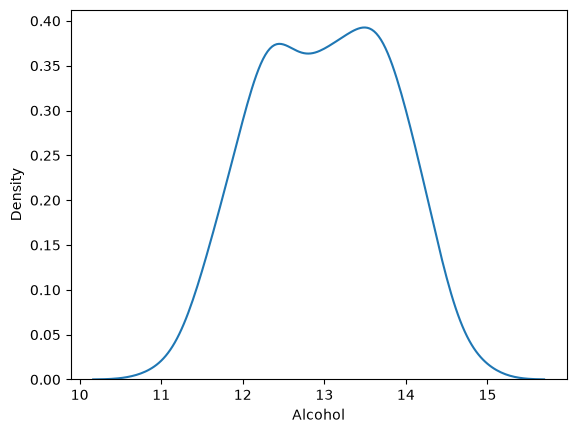

In [4]:
sns.kdeplot(data=df,x='Alcohol')
plt.show()

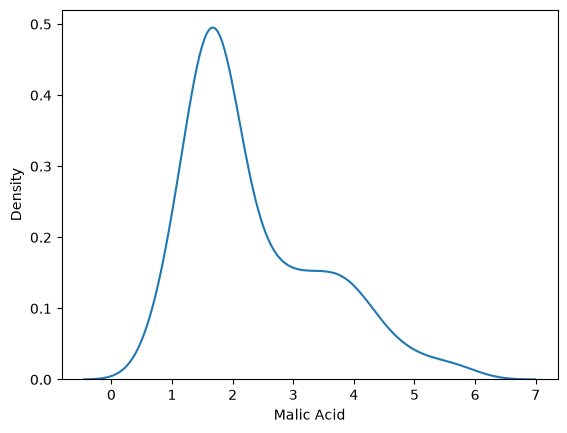

In [5]:
sns.kdeplot(data=df,x='Malic Acid')
plt.show()

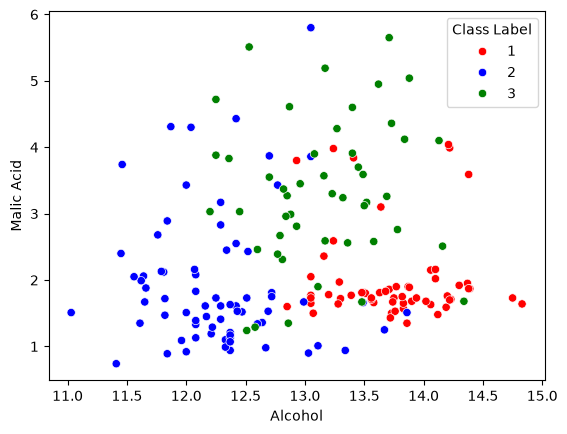

In [6]:
colors={1:'red',3:'green',2:'blue'}
sns.scatterplot(data=df,x='Alcohol',y='Malic Acid',hue='Class Label',palette=colors)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test , Y_train , Y_test = train_test_split(df.drop('Class Label',axis=1),df['Class Label'],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((124, 2), (54, 2))

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [10]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [11]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


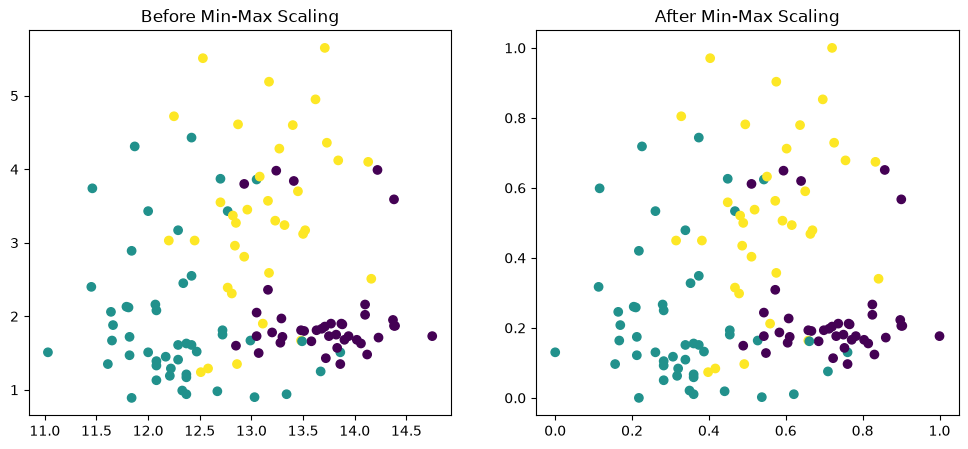

In [12]:
fig , (ax1 , ax2 ) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Alcohol'],X_train['Malic Acid'],c=Y_train)
ax1.set_title("Before Min-Max Scaling")
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic Acid'],c=Y_train)
ax2.set_title("After Min-Max Scaling")
plt.show()

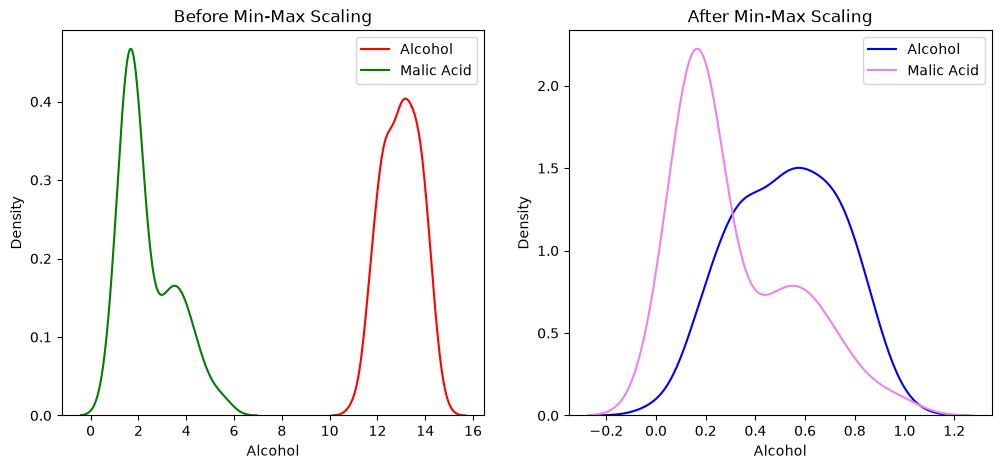

In [13]:
fig , (ax1 , ax2 ) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Before Min-Max Scaling")
sns.kdeplot(data=X_train,x='Alcohol',color='Red',label='Alcohol',ax=ax1)
sns.kdeplot(data=X_train,x='Malic Acid',color='Green',label='Malic Acid',ax=ax1)
ax1.legend()
ax2.set_title("After Min-Max Scaling")
sns.kdeplot(data=X_train_scaled,x='Alcohol',color='Blue',label='Alcohol',ax=ax2)
sns.kdeplot(data=X_train_scaled,x='Malic Acid',color='Violet',label='Malic Acid',ax=ax2)
ax2.legend()
plt.show()

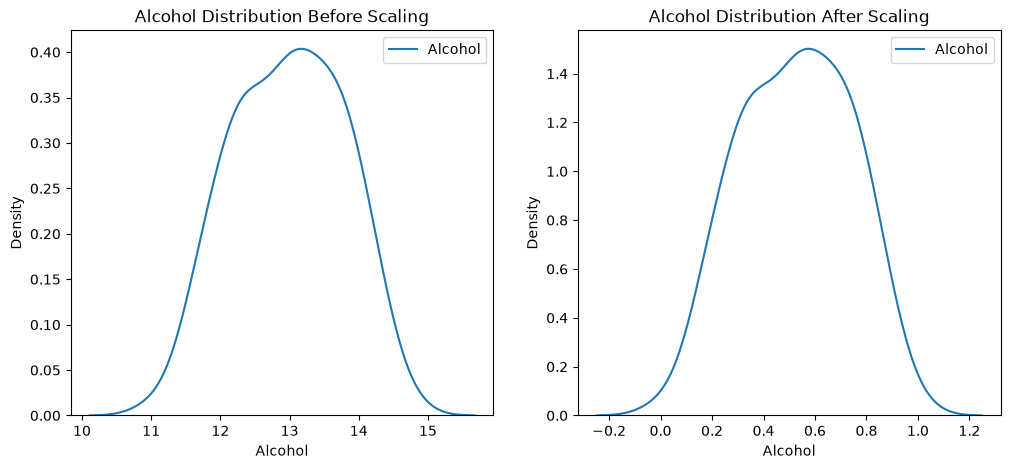

In [14]:
fig , (ax1 , ax2 ) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Alcohol Distribution Before Scaling")
sns.kdeplot(data=X_train,x='Alcohol',label='Alcohol',ax=ax1)
ax1.legend()
ax2.set_title("Alcohol Distribution After Scaling")
sns.kdeplot(data=X_train_scaled,x='Alcohol',label='Alcohol',ax=ax2)
ax2.legend()
plt.show()

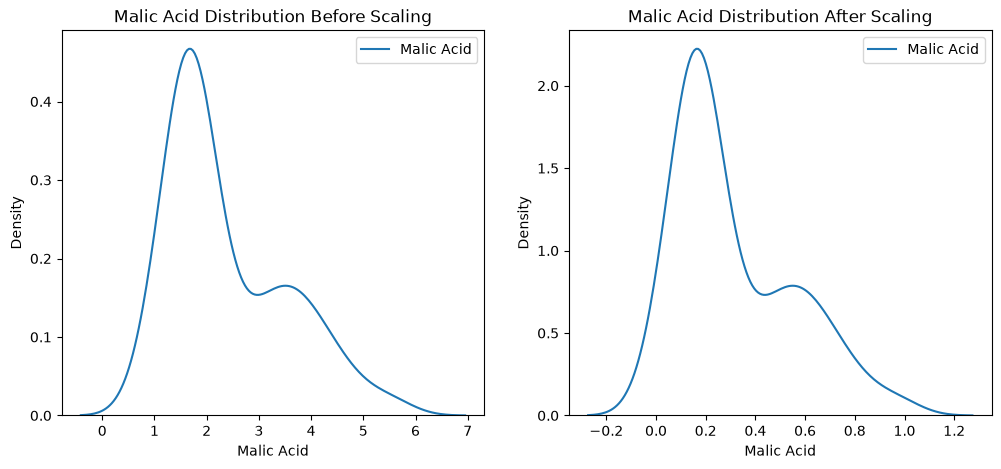

In [15]:
fig , (ax1 , ax2 ) = plt.subplots(ncols=2,figsize=(12,5))
ax1.set_title("Malic Acid Distribution Before Scaling")
sns.kdeplot(data=X_train,x='Malic Acid',label='Malic Acid',ax=ax1)
ax1.legend()
ax2.set_title("Malic Acid Distribution After Scaling")
sns.kdeplot(data=X_train_scaled,x='Malic Acid',label='Malic Acid',ax=ax2)
ax2.legend()
plt.show()

In [25]:
df = pd.read_csv('train.csv')

In [45]:
df.sample(3)

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
383237,0,0,2,5,0,0,0,0,1,0,...,4,4,3,7,1,1,0,0,0,0
357860,0,3,1,4,1,0,1,0,0,0,...,5,1,2,9,0,0,1,1,1,0
352898,0,1,1,10,1,0,0,1,0,0,...,3,1,1,6,0,1,1,0,0,1


In [27]:
df.shape

(595212, 59)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_bin   59521

In [42]:
from sklearn.preprocessing import MaxAbsScaler
df = df.drop(columns=['id'])
X= df.drop(columns=['target'])
Y = df['target']
scaler = MaxAbsScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)


In [43]:
X_scaled = pd.DataFrame(X_scaled,columns=X.columns)

In [44]:
X_scaled

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0.285714,0.50,0.454545,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.473684,0.1,0.384615,0.347826,0.0,1.0,1.0,0.0,0.0,1.0
1,0.142857,0.25,0.636364,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.157895,0.1,0.076923,0.391304,0.0,1.0,1.0,0.0,1.0,0.0
2,0.714286,1.00,0.818182,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.210526,0.2,0.538462,0.304348,0.0,1.0,1.0,0.0,1.0,0.0
3,0.000000,0.25,0.181818,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.105263,0.2,0.307692,0.391304,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.50,0.000000,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.157895,0.1,0.076923,0.130435,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,0.428571,0.25,0.909091,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.210526,0.1,0.692308,0.260870,0.0,1.0,1.0,0.0,1.0,1.0
595208,0.714286,0.25,0.272727,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.210526,0.1,0.230769,0.347826,1.0,0.0,1.0,0.0,1.0,1.0
595209,0.142857,0.25,0.909091,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.157895,0.2,0.153846,0.260870,0.0,0.0,1.0,0.0,0.0,0.0
595210,0.714286,0.50,0.272727,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.210526,0.1,0.307692,0.086957,0.0,1.0,1.0,1.0,0.0,0.0


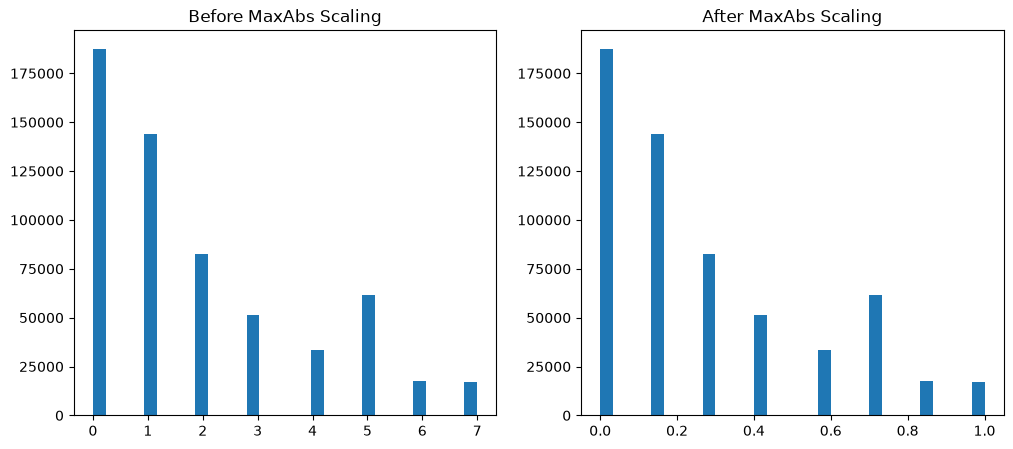

In [48]:
fig , (ax1 , ax2 ) = plt.subplots(ncols=2,figsize=(12,5))
ax1.hist(X['ps_ind_01'],bins=30)
ax1.set_title("Before MaxAbs Scaling")
ax2.hist(X_scaled['ps_ind_01'],bins=30)
ax2.set_title("After MaxAbs Scaling")
plt.show()

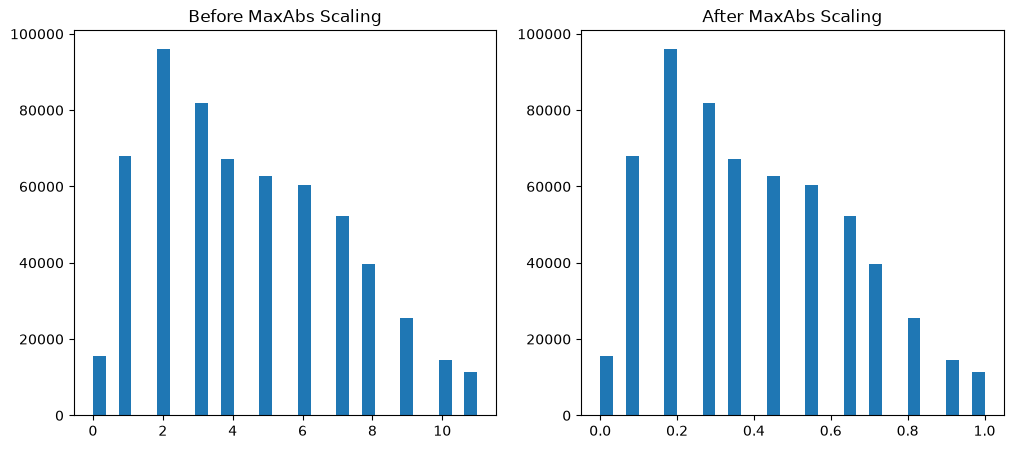

In [49]:
fig , (ax1 , ax2 ) = plt.subplots(ncols=2,figsize=(12,5))
ax1.hist(X['ps_ind_03'],bins=30)
ax1.set_title("Before MaxAbs Scaling")
ax2.hist(X_scaled['ps_ind_03'],bins=30)
ax2.set_title("After MaxAbs Scaling")
plt.show()